In [12]:
from io import StringIO
import csv
import pandas as pd
import math
from scipy.stats import pearsonr
from matplotlib import pyplot as plt
import matplotlib as mpl
import numpy as np
import re
import itertools
from collections import Counter

In [13]:
WORKDIR="../datasets/genny-range/"
YML_FILE="rc-experiment.yml"

In [14]:
%%capture output
%%bash -s "$WORKDIR" "$YML_FILE"
cd $1;
./postprocess.sh timing_stats $2

In [15]:
stats = output
stats_csv = stats.stdout


In [16]:
%%capture output
%%bash -s "$WORKDIR" "$YML_FILE"
cd $1;
./postprocess.sh genny_stats $2

In [17]:
genny = output
genny_csv = genny.stdout
genny_csv


'Patch ID,Execution,Task Name,Topology,Test,OperationsTotal,DocumentsTotal,SizeTotal,DurationTotal,OverheadTotal,ErrorsTotal,AverageLatency,AverageSize,OperationThroughput,DocumentThroughput,SizeThroughput,LatencyMin,LatencyMax,Latency50thPercentile,Latency80thPercentile,Latency90thPercentile,Latency95thPercentile,Latency99thPercentile,WorkersMin,WorkersMax,ErrorRate\n660d8ca7812d470007777361,0,qe_range_testing_workloads_evergreen_qe_range_rc_age_t_read100_encrypted,perf-shard-lite-fle.arm.aws.2023-11,FSMActor_Thread9.FSM.range_query,6250,317296,485780176,151479792262,3165979951176,0,24217080.83952,77724.82816,41.259628803754744,2094.6424289465867,3206897.558717224,2605877,160792262,24157049.5,32089329.599999998,36054823.36666667,39450941.149999976,46038069.61,1,1,0\n660d8ca7812d470007777361,0,qe_range_testing_workloads_evergreen_qe_range_rc_age_t_read100_encrypted,perf-shard-lite-fle.arm.aws.2023-11,FSMActor_Thread2.FSM.range_query,6250,317642,486309902,151296402090,3165992573737,0,24

In [18]:
%%capture output
%%bash -s "$WORKDIR" "$YML_FILE"
cd $1;
./postprocess.sh storage_stats $2

In [19]:
storage = output
storage_csv = storage.stdout


In [20]:
f = StringIO(stats_csv)
timing_stats = pd.read_csv(f)
timing_stats

f2 = StringIO(genny_csv)
genny_stats = pd.read_csv(f2)
genny_stats

f3 = StringIO(storage_csv)
storage_stats = pd.read_csv(f3)
storage_stats

timing_stats.to_pickle('summ_stats.pkl')
genny_stats.to_pickle('genny_stats.pkl')
storage_stats.to_pickle('storage_stats.pkl')

In [21]:
timing_stats = pd.read_pickle('summ_stats.pkl')
genny_stats = pd.read_pickle('genny_stats.pkl')
storage_stats = pd.read_pickle('storage_stats.pkl')

In [ ]:
def add_info(stats, header):
    contentions = []
    sparsities = []
    upper_bounds = []
    range_size_is_big = []

    for name in stats["Task Name"]:
        print(name)
        start = name.find(header) + len(header)
        c_idx = name.find('c', start)
        s_idx = name.find('s', start)
        ub_idx = name.find('ub', start)
        ub_end_idx = name.find('_', ub_idx)
        if name.find('big', start) != -1:
            range_size_is_big.append(1)
        elif name.find('small', start) != -1:
            range_size_is_big.append(0)
        contentions.append(int(name[c_idx + 1]))
        sparsities.append(int(name[s_idx + 1]))
        if ub_end_idx == -1:
            upper_bounds.append(int(round(math.log2(int(name[ub_idx + 2:])))))
        else:
            upper_bounds.append(int(round(math.log2(int(name[ub_idx + 2:ub_end_idx])))))

    if len(range_size_is_big) == len(stats.index):
        stats['big_range'] = range_size_is_big
    else:
        assert len(range_size_is_big) == 0
    stats["contention"] = contentions
    stats["sparsity"] = sparsities
    stats["log_upper_bound"] = upper_bounds

def split_stats(stats):
    unencrypted = []
    experiment0 = [] #pd.DataFrame(columns=stats.columns)
    experiment1 = []
    for _, row in stats.iterrows():
        if row['Task Name'] == 'qe_range_testing_workloads_evergreen_experiment1_1_storage_unencrypted':
            unencrypted.append(row)
        elif row['Task Name'].find('experiment0') != -1:
            experiment0.append(row)
        elif row['Task Name'].find('experiment1') != -1:
            experiment1.append(row)
    return pd.DataFrame(data=unencrypted, columns=stats.columns), pd.DataFrame(data=experiment0, columns=stats.columns), pd.DataFrame(data=experiment1, columns=stats.columns)
    
_, exp0genny, exp1genny = split_stats(genny_stats)
storage_unencrypted, storage_exp0, storage_exp1 = split_stats(storage_stats)
add_info(exp1genny, 'experiment1_1')
add_info(exp0genny, 'experiment0')
add_info(storage_exp1, 'experiment1_1')
add_info(storage_exp0, 'experiment0')


In [ ]:
pattern = r"qe_range_testing_workloads_evergreen_experiment2_(?P<is_encrypted>[a-z]+)_(?P<field_name>[a-z0-9_]+?)(?:_sp(?P<sparsity>[0-9]+)_cf(?P<contention>[0-9]+))?_sel(?P<sel>[0-9]+)_(?P<query_type>[a-z]+)"
keys_to_add = {}
for name in storage_stats["Task Name"]:
    print(name)
    d = re.match(pattern, name).groupdict()
    for k, v in d.items():
        if k not in keys_to_add:
            keys_to_add[k] = []
        keys_to_add[k].append(v)

for k, v in keys_to_add.items():
    storage_stats[k] = v


In [ ]:
pattern = r"qe_range_testing_workloads_evergreen_experiment_i1_(?P<Sis_encrypted>[a-z]+)_(?P<Ssame_diff>[a-z]+)(?:_(?:(?P<Sis_equality>[a-z]+)_)?c(?P<Icontention>[0-9]+)_s(?P<Isparsity>[0-9]+))?(?:_ub(?P<Iupper_bound>[0-9]+))?"

for st in [timing_stats, genny_stats, storage_stats]:
    keys_to_add = {}
    for name in st["Task Name"]:
        print(name)
        d = re.match(pattern, name).groupdict()
        for k, v in d.items():
            if k[0] == 'I':
                v = int(v) if v is not None else -1
            elif k[0] == 'S':
                v = str(v) if v is not None else ""
            k = k[1:]
            if k not in keys_to_add:
                keys_to_add[k] = []
            keys_to_add[k].append(v)

    for k, v in keys_to_add.items():
        st[k] = v



In [ ]:
pattern_iht = r"qe_range_testing_workloads_evergreen_experiment_iht_(?P<Ssame_diff>[a-z]+)_(?:(?P<Sis_encrypted>unencrypted)_)?(?:(?P<Sis_equality>equality)_)?(?:c(?P<Icontention>[0-9]+)_)?(?:s(?P<Isparsity>[0-9]+)_)?ub(?P<Iupper_bound>[0-9]+)(?:_tf(?P<Itrim_factor>[0-9]+))?"
pattern_i1 = r"qe_range_testing_workloads_evergreen_experiment_i1_(?P<Sis_encrypted>[a-z]+)_(?P<Ssame_diff>[a-z]+)(?:_(?:(?P<Sis_equality>[a-z]+)_)?c(?P<Icontention>[0-9]+)_s(?P<Isparsity>[0-9]+))?(?:_ub(?P<Iupper_bound>[0-9]+))?"
with open('rs_tester.txt') as f:
    test_list = [s.strip() for s in f.readlines()]

for st in [timing_stats, storage_stats, genny_stats]:
    keys_to_add = {}
    for name in st["Task Name"]:
        if 'experiment_iht' in name:
            d = re.match(pattern_iht, name).groupdict()
            d['Sis_encrypted'] = d['Sis_encrypted'] if d['Sis_encrypted'] is not None else 'encrypted'
        else:
            assert 'experiment_i1' in name
            d = re.match(pattern_i1, name).groupdict()
            d['Itrim_factor'] = None
            if d['Iupper_bound'] is None:
                d['Iupper_bound'] = 2**31-1
        #print(name)
        for k, v in d.items():
            if k[0] == 'I':
                v = int(v) if v is not None else -1
            elif k[0] == 'S':
                v = str(v) if v is not None else ""
            k = k[1:]
            if k not in keys_to_add:
                keys_to_add[k] = []
            keys_to_add[k].append(v)

    for k, v in keys_to_add.items():
        st[k] = v

    import collections
    for k, v in keys_to_add.items():
        print(k, collections.Counter(v))

for test in test_list:
    if test not in set(st['Task Name']):
        print('Missing test:', test)
print('unqiue tasks', st['Task Name'].nunique())




In [3]:
pattern = r"qe_range_testing_workloads_evergreen_experiment_i2_(?P<Squery>[a-z]+)_(?P<Sfield>[a-z]+_[a-z]+)(?:_c(?P<Icontention>[0-9]+)(?:_s(?P<Isparsity>[0-9]+)_tf(?P<Itrim_factor>[0-9]+))?)?"
# with open('rs_tester.txt') as f:
#     test_list = [s.strip() for s in f.readlines()]

for st in [timing_stats, storage_stats, genny_stats]:
    keys_to_add = {}
    for name in st["Task Name"]:
        d = re.match(pattern, name).groupdict()
        #print(name)
        for k, v in d.items():
            if k[0] == 'I':
                v = int(v) if v is not None else -1
            elif k[0] == 'S':
                v = str(v) if v is not None else ""
            k = k[1:]
            if k not in keys_to_add:
                keys_to_add[k] = []
            keys_to_add[k].append(v)

    for k, v in keys_to_add.items():
        st[k] = v

    import collections
    for k, v in keys_to_add.items():
        print(k, collections.Counter(v))

# for test in test_list:
#     if test not in set(st['Task Name']):
#         print('Missing test:', test)
print('unqiue tasks', st['Task Name'].nunique())




query Counter({'ran': 240, 'eq': 12, 'unenc': 4})
field Counter({'uniform_big': 64, 'uniform_small': 64, 'zipf_big': 64, 'zipf_small': 64})
contention Counter({0: 84, 4: 84, 8: 84, -1: 4})
sparsity Counter({1: 60, 2: 60, 3: 60, 4: 60, -1: 16})
trim_factor Counter({0: 48, 2: 48, 4: 48, 6: 48, 8: 48, -1: 16})
query Counter({'ran': 240, 'eq': 12, 'unenc': 4})
field Counter({'uniform_big': 64, 'uniform_small': 64, 'zipf_big': 64, 'zipf_small': 64})
contention Counter({0: 84, 4: 84, 8: 84, -1: 4})
sparsity Counter({1: 60, 2: 60, 3: 60, 4: 60, -1: 16})
trim_factor Counter({0: 48, 2: 48, 4: 48, 6: 48, 8: 48, -1: 16})
query Counter({'ran': 1920, 'eq': 96, 'unenc': 32})
field Counter({'uniform_big': 512, 'uniform_small': 512, 'zipf_big': 512, 'zipf_small': 512})
contention Counter({0: 672, 4: 672, 8: 672, -1: 32})
sparsity Counter({1: 480, 2: 480, 3: 480, 4: 480, -1: 128})
trim_factor Counter({0: 384, 2: 384, 4: 384, 6: 384, 8: 384, -1: 128})
unqiue tasks 256


In [ ]:
pattern = r"qe_range_testing_test_workloads_trim_testing_(?P<Ssame_diff>[a-z]+)_(?P<Itrim_factor>[0-9]+)"

for st in [timing_stats, genny_stats, storage_stats]:
    keys_to_add = {}
    for name in st["Task Name"]:
        print(name)
        d = re.match(pattern, name).groupdict()
        for k, v in d.items():
            if k[0] == 'I':
                v = int(v) if v is not None else -1
            elif k[0] == 'S':
                v = str(v) if v is not None else ""
            k = k[1:]
            if k not in keys_to_add:
                keys_to_add[k] = []
            keys_to_add[k].append(v)

    for k, v in keys_to_add.items():
        st[k] = v



In [13]:
pattern = r"qe_range_testing_workloads_evergreen_experiment_q3_(?P<Squery_type>[a-z]+)_sel(?P<Isel>[0-9]+)_c(?P<Icontention>[0-9]+)_s(?P<Isparsity>[0-9]+)_tf(?P<Itrim_factor>[0-9]+)"
for st in [timing_stats, genny_stats, storage_stats]:
    keys_to_add = {}
    for name in st["Task Name"]:
        print(name)
        d = re.match(pattern, name).groupdict()
        for k, v in d.items():
            if k[0] == 'I':
                v = int(v) if v is not None else -1
            elif k[0] == 'S':
                v = str(v) if v is not None else ""
            k = k[1:]
            if k not in keys_to_add:
                keys_to_add[k] = []
            keys_to_add[k].append(v)

    for k, v in keys_to_add.items():
        st[k] = v

    



qe_range_testing_workloads_evergreen_qe_range_rc_age_t_insert_only_cf16_tf6


AttributeError: 'NoneType' object has no attribute 'groupdict'

In [22]:
# pattern = r'qe_range_testing_workloads_evergreen_qe_range_rc_(?P<Sfield_name>[a-z]+)_(?P<Stemplate>[a-z0-9]+)_(read(?P<Iread_percent>[0-9]+)|(?P<Swrite_only>insert_only))_((?P<Sunencrypted>unencrypted)|cf(?P<Icontention>[0-9]+)_tf(?P<Isparsity>[0-9]+))'
pattern = r'qe_range_testing_workloads_evergreen_qe_range_rc_((?P<Sfield_name>[a-z]+)_(?P<Stemplate>[a-z0-9]+)_read(?P<Iread_percent>[0-9]+)|(?P<Swrite_only>insert_only))_(?P<Sencrypted>encrypted|unencrypted)'
for st in [timing_stats, genny_stats, storage_stats]:
    keys_to_add = {}
    for name in st["Task Name"]:
        print(name)
        d = re.match(pattern, name).groupdict()
        for k, v in d.items():
            if k[0] == 'I':
                v = int(v) if v is not None else -1
            elif k[0] == 'S':
                v = str(v) if v is not None else ""
            k = k[1:]
            if k not in keys_to_add:
                keys_to_add[k] = []
            keys_to_add[k].append(v)

    # print(keys_to_add.keys())

    for k, v in keys_to_add.items():
        st[k] = v

    import collections
    for k, v in keys_to_add.items():
        print(k, collections.Counter(v))



qe_range_testing_workloads_evergreen_qe_range_rc_age_t_read100_encrypted
qe_range_testing_workloads_evergreen_qe_range_rc_age_t_read100_unencrypted
qe_range_testing_workloads_evergreen_qe_range_rc_age_t_read50_encrypted
qe_range_testing_workloads_evergreen_qe_range_rc_age_t_read50_unencrypted
qe_range_testing_workloads_evergreen_qe_range_rc_age_t_read95_encrypted
qe_range_testing_workloads_evergreen_qe_range_rc_age_t_read95_unencrypted
qe_range_testing_workloads_evergreen_qe_range_rc_balance_t1_read100_encrypted
qe_range_testing_workloads_evergreen_qe_range_rc_balance_t1_read100_unencrypted
qe_range_testing_workloads_evergreen_qe_range_rc_balance_t1_read50_encrypted
qe_range_testing_workloads_evergreen_qe_range_rc_balance_t1_read50_unencrypted
qe_range_testing_workloads_evergreen_qe_range_rc_balance_t1_read95_encrypted
qe_range_testing_workloads_evergreen_qe_range_rc_balance_t1_read95_unencrypted
qe_range_testing_workloads_evergreen_qe_range_rc_balance_t2_read100_encrypted
qe_range_tes

In [23]:
# RC
Counter(genny_stats['Test'])
rc_fields = set(genny_stats['field_name'])
rc_fields.remove('')
# field_cf_tf = {'timestamp': (4, 8), 'age': (8, 6), 'balance': (8, 6)}


In [24]:
# rc insert perf
filt = genny_stats[(genny_stats['write_only'] == 'insert_only') & (genny_stats['encrypted'] == 'encrypted')]
print(filt.columns)
print(filt.Execution)
print(filt.OperationThroughput.sum())
# for field in rc_fields:
#     stats_filt = genny_stats[(genny_stats['field_name'] == field) & (genny_stats['write_only'] == 'insert_only')]
#     #print(stats_filt)
#     for t in stats_filt['Test']:
#         assert t.startswith('InsertActor')

#     grouped = stats_filt.groupby(['read_percent', 'write_only', 'unencrypted', 'contention', 'sparsity'])
#     for group in grouped:
#         assert(len(group[1]) % 8 == 0)

#         print(field, group[0], group[1]['OperationThroughput'].mean() * 8)

Index(['Patch ID', 'Execution', 'Task Name', 'Topology', 'Test',
       'OperationsTotal', 'DocumentsTotal', 'SizeTotal', 'DurationTotal',
       'OverheadTotal', 'ErrorsTotal', 'AverageLatency', 'AverageSize',
       'OperationThroughput', 'DocumentThroughput', 'SizeThroughput',
       'LatencyMin', 'LatencyMax', 'Latency50thPercentile',
       'Latency80thPercentile', 'Latency90thPercentile',
       'Latency95thPercentile', 'Latency99thPercentile', 'WorkersMin',
       'WorkersMax', 'ErrorRate', 'field_name', 'template', 'read_percent',
       'write_only', 'encrypted'],
      dtype='object')
1152    0
1153    0
1154    0
1155    0
1156    0
1157    0
1158    0
1159    0
1160    0
1161    0
1162    0
1163    0
1164    0
1165    0
1166    0
1167    0
Name: Execution, dtype: int64
318.17040237982735


In [38]:
# rc query perf
total_dict = {}
for field in rc_fields:
    update_filt = genny_stats[(genny_stats['field_name'] == field)  & (genny_stats['Test'].str.contains('update')) & (genny_stats['encrypted'] == 'encrypted')]
    query_filt = genny_stats[(genny_stats['field_name'] == field)  & (genny_stats['Test'].str.contains('range_query')) & (genny_stats['encrypted'] == 'encrypted')]
    # print(update_filt)
    # print(query_filt)

    # print('uf', update_filt['Test'])
    # print(update_filt.columns.values)
    ugrouped = update_filt.groupby(['template', 'read_percent', 'write_only'])
    
    for group in ugrouped:
        if group[0][1] == 100:
            continue
        #print(len(group[1]))
        # print(group[1])
        # print('g1', group[1]['Test'])

        #print(field, 'update', group[0], group[1]['Latency95thPercentile'].mean() / 10**6, group[1]['Latency80thPercentile'].mean() / 10**6, group[1]['Latency50thPercentile'].mean() / 10**6)
        total_dict[(field, 'u') + group[0][:2]] = (group[1]['Latency95thPercentile'].mean() / 10**6, group[1]['Latency80thPercentile'].mean() / 10**6, group[1]['Latency50thPercentile'].mean() / 10**6)

    qgrouped = query_filt.groupby(['template', 'read_percent', 'write_only'])
    
    for group in qgrouped:

        # print(group[1])
        # print('g1', group[1]['Test'])
        # assert(len(group[1]) == 1)

        #print(field, 'query', group[0], group[1]['Latency95thPercentile'].mean() / 10**6, group[1]['Latency80thPercentile'].mean() / 10**6, group[1]['Latency50thPercentile'].mean() / 10**6)
        total_dict[(field, 'q') + group[0][:2]] = (group[1]['Latency95thPercentile'].mean() / 10**6, group[1]['Latency80thPercentile'].mean() / 10**6, group[1]['Latency50thPercentile'].mean() / 10**6)

keys = list(total_dict.keys())
def _skey(tup):
    (field, uq, t, p) = tup
    return (field, t, str(98-p) + uq)
skeys = sorted(keys, key=_skey)

for k in skeys:
    p95, p80, p50 = total_dict[k]
    print(k, p95, p80, p50)

('age', 'q', 't', 100) 39.06224899374998 31.8073273625 24.0636266875
('age', 'q', 't', 95) 41.17678004687499 32.71872235 24.53682146875
('age', 'u', 't', 95) 23.26913239999999 18.3426483 15.47201421875
('age', 'q', 't', 50) 43.48852366875001 33.290450425 24.3751805
('age', 'u', 't', 50) 37.429479796875015 22.56369167500001 15.0899196875
('balance', 'q', 't1', 100) 46.546054024999975 37.55698108749999 29.33448590625
('balance', 'q', 't1', 95) 51.23577237812498 40.947486875 31.762444
('balance', 'u', 't1', 95) 29.920322681249978 21.85268075 18.48077425
('balance', 'q', 't1', 50) 56.73488202500001 43.917006575 33.034883125
('balance', 'u', 't1', 50) 65.73512920937503 35.981522800000015 20.5907645625
('balance', 'q', 't2', 100) 93.21851825 80.2323659625 67.814779125
('balance', 'q', 't2', 95) 94.51328623749998 80.79661719999999 68.0135461875
('balance', 'u', 't2', 95) 26.453214834374986 20.730754287499998 18.05169075
('balance', 'q', 't2', 50) 106.11464596562502 87.55375521250001 71.448217

In [ ]:
# Q3
# genny_filt = genny_stats[(genny_stats['query_type'] == 'rand') & (genny_stats['Test'] != 'PreDefinedRangeQueryActor.query.range_query')]
# Counter(genny_filt['Test'])
# summed_throughput = genny_filt.groupby(by=['sel', 'contention', 'sparsity', 'trim_factor'])['OperationThroughput'].sum().reset_index()
# summed_throughput.to_pickle('q3_summed_throughput.pkl')

In [4]:
# Q3
# print(genny_stats.columns)
# print(genny_stats.groupby(by=['query', 'field', 'contention', 'sparsity', 'trim_factor']).count().reset_index())
# op_throughput = genny_stats.groupby(by=['query', 'field', 'contention', 'sparsity', 'trim_factor'])['OperationThroughput'].sum().reset_index()

# print(op_throughput)

Index(['Patch ID', 'Execution', 'Task Name', 'Topology', 'Test',
       'OperationsTotal', 'DocumentsTotal', 'SizeTotal', 'DurationTotal',
       'OverheadTotal', 'ErrorsTotal', 'AverageLatency', 'AverageSize',
       'OperationThroughput', 'DocumentThroughput', 'SizeThroughput',
       'LatencyMin', 'LatencyMax', 'Latency50thPercentile',
       'Latency80thPercentile', 'Latency90thPercentile',
       'Latency95thPercentile', 'Latency99thPercentile', 'WorkersMin',
       'WorkersMax', 'ErrorRate', 'query', 'field', 'contention', 'sparsity',
       'trim_factor'],
      dtype='object')
     query          field  contention  sparsity  trim_factor  Patch ID  \
0       eq    uniform_big           0        -1           -1         8   
1       eq    uniform_big           4        -1           -1         8   
2       eq    uniform_big           8        -1           -1         8   
3       eq  uniform_small           0        -1           -1         8   
4       eq  uniform_small           4 

In [14]:
#experiment i2 table

FIELDS = ['uniform_big', 'uniform_small', 'zipf_big', 'zipf_small']
for field in FIELDS:
    filtered = op_throughput[(op_throughput['field'] == field) & (op_throughput['query'] == 'ran')]
    a = filtered.groupby(by=['trim_factor', 'contention', 'sparsity']).OperationThroughput.mean()
    print(field)
    print(a.idxmax(), a[a.idxmax()])
    print(a.idxmin(), a[a.idxmin()])
    print((6, 4, 2), a[(6, 4, 2)])



uniform_big
(8, 4, 4) 1104.7775156401428
(0, 0, 1) 110.72739335110961
(6, 4, 2) 792.3621435558849
uniform_small
(6, 8, 4) 837.3743834415393
(0, 0, 1) 115.7813845464604
(6, 4, 2) 518.1632914522911
zipf_big
(8, 8, 4) 1253.4006918435048
(0, 0, 1) 199.59316908294082
(6, 4, 2) 859.5558672356573
zipf_small
(6, 8, 4) 1434.8622261842477
(0, 0, 1) 284.16246897952226
(6, 4, 2) 1057.111875620438


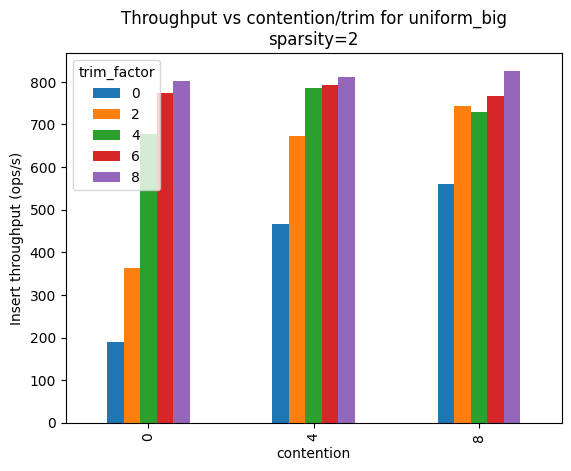

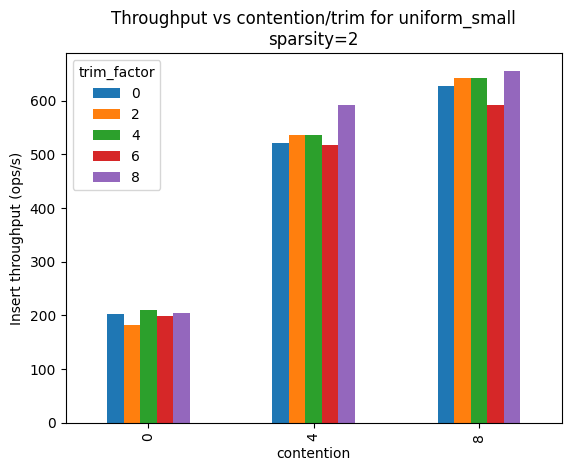

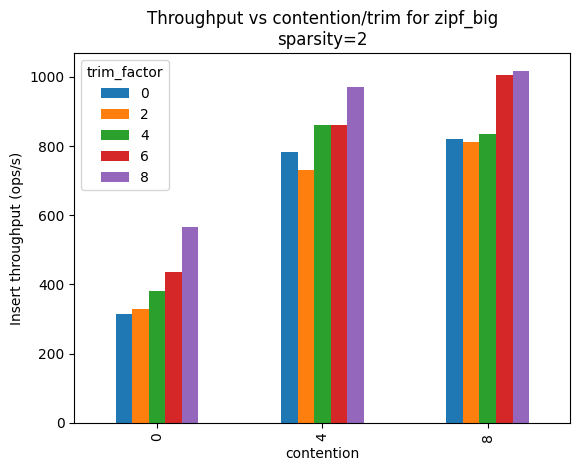

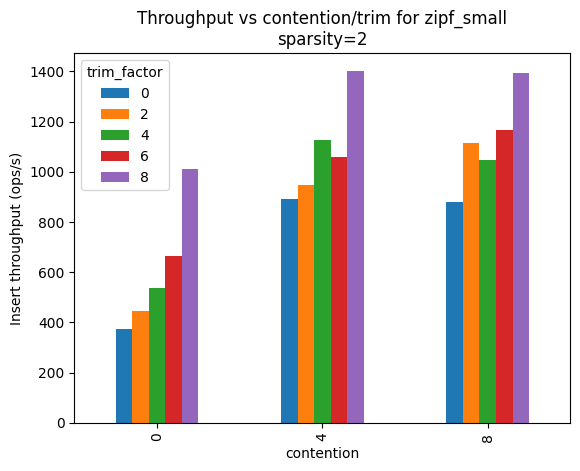

In [19]:
#experiment i2 second graphs

for field in FIELDS:
    for sp in [2]: #1,2,3,4
        filtered = op_throughput[(op_throughput['field'] == field) & (op_throughput['query'] == 'ran') & (op_throughput['sparsity'] == sp)]
        filtered
        filtered.groupby(by=['contention', 'trim_factor']).OperationThroughput.mean().unstack(level=1).plot.bar()
        plt.title(f'Throughput vs contention/trim for {field}\nsparsity={sp}')
        plt.ylabel('Insert throughput (ops/s)')
        plt.show()
        plt.close()


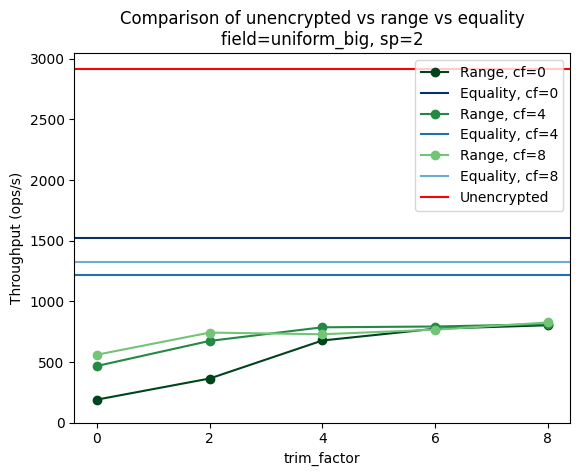

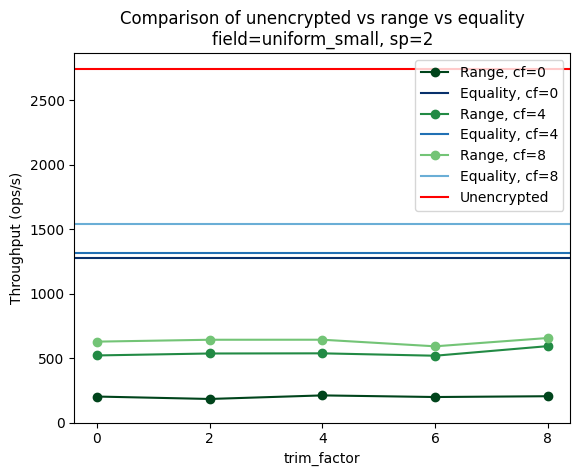

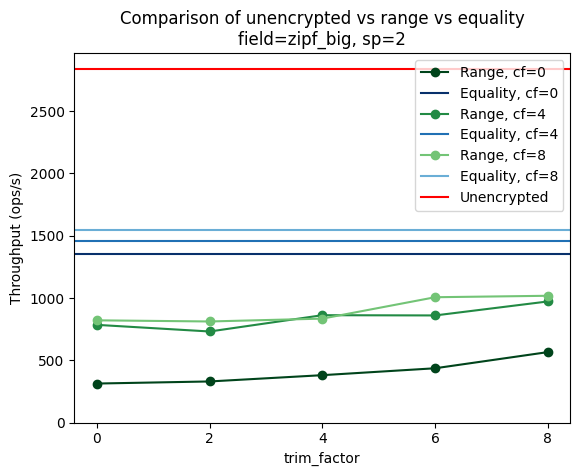

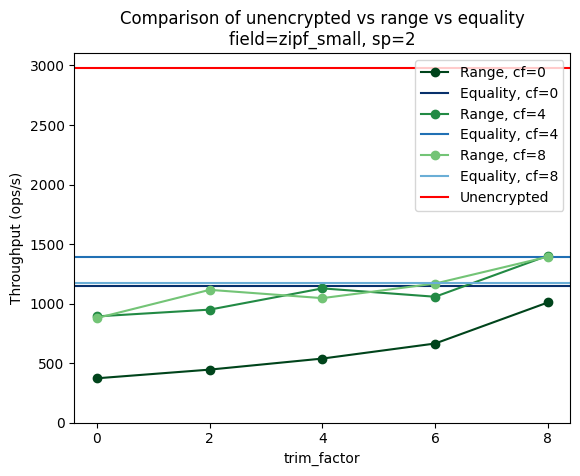

In [13]:
#experiment i2 graphs
plt.ioff()
blues = itertools.cycle(iter(mpl.cycler('color', [plt.get_cmap('Blues')(1-1. * i/4) for i in range(3)])))
greens = itertools.cycle(iter(mpl.cycler('color', [plt.get_cmap('Greens')(1-1. * i/4) for i in range(3)])))

for field in FIELDS:
    filtered = op_throughput[op_throughput['field'] == field]
    unenc_data = filtered[filtered['query'] == 'unenc']
    eq_data = filtered[filtered['query'] == 'eq']
    ran_data = filtered[(filtered['query'] == 'ran') & (filtered['sparsity'] == 2)]
    for cf in [0, 4, 8]:
        ran_data[ran_data.contention == cf].groupby(by=['trim_factor'])['OperationThroughput'].mean().plot(style='o-', label=f'Range, cf={cf}', **next(greens))
        plt.axhline(eq_data[eq_data.contention == cf].OperationThroughput.mean(), label=f'Equality, cf={cf}', **next(blues))
    plt.axhline(y=unenc_data.OperationThroughput.mean(), label='Unencrypted', color='red')
    plt.legend()
    plt.ylabel('Throughput (ops/s)')
    plt.title(f'Comparison of unencrypted vs range vs equality\nfield={field}, sp=2')
    plt.xticks([0,2,4,6,8])
    plt.ylim(bottom=0)
    plt.show()
    plt.close()




In [ ]:
#experiment i1 graphs

# #print(genny_stats[genny_stats['is_encrypted']=='unencrypted'].groupby('same_diff')['OperationThroughput'].mean().to_string())
# op_throughput = genny_stats.groupby(by=['same_diff', 'trim_factor'])['OperationThroughput'].sum().reset_index()
# print(op_throughput)

# for sd in ['same', 'diff']:
#     a = op_throughput[op_throughput['same_diff'] == sd].groupby('trim_factor')['OperationThroughput'].mean().plot(style='o-', label=f"Range, {'single value' if sd == 'same' else 'distinct values'}")
# plt.axhline(419, color='red', label='Equality, single value')
# plt.axhline(1435, color='green', label='Equality, distinct values')
# plt.xticks([0, 2, 4, 6, 8])
# plt.ylim(bottom=0)
# plt.ylabel('Throughput (docs/s)')
# plt.xlabel('Trim factor')
# plt.legend()
# plt.title('Throughput vs trim factor, range vs equality comparison\nContention=0, sparsity=1, upper bound=131071')
# plt.show()
# plt.close()

In [ ]:
# iht analysis

#(?P<Ssame_diff>[a-z]+)_(?:(?P<Sis_encrypted>unencrypted)_)?(?:(?P<Sis_equality>equality)_)?(?:c(?P<Icontention>[0-9]+)_)?(?:s(?P<Isparsity>[0-9]+)_)?ub(?P<Iupper_bound>[0-9]+)(?:_tf(?P<Itrim_factor>[0-9]+
#print(genny_stats[genny_stats['is_encrypted']=='unencrypted'].groupby('same_diff')['OperationThroughput'].mean().to_string())
op_throughput = genny_stats.groupby(by=['same_diff', 'is_encrypted', 'is_equality', 'contention', 'sparsity', 'upper_bound', 'trim_factor'])['OperationThroughput'].sum().reset_index()
eq_data = op_throughput[op_throughput['is_equality'] == 'equality']
ran_data = op_throughput[(op_throughput['is_encrypted'] == 'encrypted') & (op_throughput['is_equality'] == '')]
unenc_data = op_throughput[op_throughput['is_encrypted'] == 'unencrypted']
print(op_throughput)

In [ ]:
#iht graphs

blues = itertools.cycle(iter(mpl.cycler('color', [plt.get_cmap('Blues')(1-1. * i/6) for i in range(5)])))
oranges = itertools.cycle(iter(mpl.cycler('color', [plt.get_cmap('Oranges')(1-1. * i/6) for i in range(5)])))


for ub in [2**10-1, 2**15-1, 2**31-1]:
    for cf in [0, 4, 8]:
        eq_same = eq_data[(eq_data['same_diff'] == 'same') & (eq_data['contention'] == cf)]
        assert set(eq_same['upper_bound']) == {2**31-1}
        eq_diff = eq_data[(eq_data['same_diff'] == 'diff') & (eq_data['contention'] == cf) & (eq_data['upper_bound'] == ub)]
        ran_fil = ran_data[(ran_data['contention'] == cf) & (ran_data['upper_bound'] == ub)]
        ran_same = ran_fil[ran_fil['same_diff'] == 'same']
        ran_diff = ran_fil[ran_fil['same_diff'] == 'diff']
        assert len(eq_same) == 1
        assert len(eq_diff) == 1
        plt.axhline(eq_same.OperationThroughput.mean(), label='Equality SV', **next(blues))
        plt.axhline(eq_diff.OperationThroughput.mean(), label='Equality DV', **next(oranges))
        for sp in [4, 3, 2, 1]:
            ran_same[ran_same['sparsity'] == sp].groupby(by='trim_factor').OperationThroughput.mean().plot(style='o-', label=f'Range SV, sp={sp}', **next(blues))
            ran_diff[ran_diff['sparsity'] == sp].groupby(by='trim_factor').OperationThroughput.mean().plot(style='o-', label=f'Range DV, sp={sp}', **next(oranges))
        ax = plt.gca()
        handles, labels = ax.get_legend_handles_labels()
        new_lh = sorted(zip(labels, handles), key=lambda t: t[0])
        labels, handles = zip(*new_lh)

        box = ax.get_position()
        ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

        plt.legend(labels=labels, handles=handles, loc='center left', bbox_to_anchor=(1, 0.5))
        plt.ylim(bottom=0)
        plt.title(f'Range vs equality comparison w/ trim factor\nupper bound={ub}, contention={cf}')
        plt.xlabel('Trim factor')
        plt.ylabel('Throughput (docs/s)')
        plt.savefig(f'figures/range_vs_equality_sp_split_ub{ub}_cf{cf}.png')
        plt.close()
        
        

In [ ]:
# experiment iht graph 2
greens = itertools.cycle(iter(mpl.cycler('color', [plt.get_cmap('Greens')(1-1. * i/6) for i in range(5)])))
reds = itertools.cycle(iter(mpl.cycler('color', [plt.get_cmap('Reds')(1-1. * i/6) for i in range(5)])))
for ub in [2**10-1, 2**15-1, 2**31-1]:
    for sp in [1, 2, 3, 4]:
        data_view = ran_data[(ran_data['upper_bound'] == ub) & (ran_data['sparsity'] == sp)]
        ax = plt.axes()
        plt.axhline(0, color='gray', linestyle='--')
        a = data_view[data_view['same_diff'] == 'diff'].groupby(by=['contention', 'trim_factor']).OperationThroughput.mean().unstack(level=1).plot.bar(ax=ax, alpha=1, color=[list(next(greens).values())[0] for _ in range(5)])
        a = data_view[data_view['same_diff'] == 'same'].groupby(by=['contention', 'trim_factor']).OperationThroughput.mean().unstack(level=1).plot.bar(ax=ax, alpha=0.5, color=[list(next(reds).values())[0] for _ in range(5)])
        
        handles, _ = ax.get_legend_handles_labels()
        handles = handles[1:]
        labels = [f'SV, tf={tf}' for tf in [0,2,4,6,8]] + [f'DV, tf={tf}' for tf in [0,2,4,6,8]]

        box = ax.get_position()
        ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

        ticks = ax.get_yticks()
        ax.set_yticklabels([int(abs(tick)) for tick in ticks])
        plt.legend(handles=handles, labels=labels, loc='center left', bbox_to_anchor=(1, 0.5))
        plt.ylabel('Throughput (docs/s)')
        plt.title(f'Throughput vs contention, trim factor, SV vs DV\nupper bound={ub}, sparsity={sp}')
        plt.show()
        plt.close()

        data_view.loc[data_view['same_diff'] == 'same', 'OperationThroughput'] *= -1
        ax = plt.axes()
        plt.axhline(0, color='gray', linestyle='--')
        a = data_view[data_view['same_diff'] == 'same'].groupby(by=['contention', 'trim_factor']).OperationThroughput.mean().unstack(level=1).plot.bar(ax=ax, color=[list(next(reds).values())[0] for _ in range(5)])
        a = data_view[data_view['same_diff'] == 'diff'].groupby(by=['contention', 'trim_factor']).OperationThroughput.mean().unstack(level=1).plot.bar(ax=ax, color=[list(next(greens).values())[0] for _ in range(5)])
        handles, _ = ax.get_legend_handles_labels()
        handles = handles[1:]
        labels = [f'SV, tf={tf}' for tf in [0,2,4,6,8]] + [f'DV, tf={tf}' for tf in [0,2,4,6,8]]

        box = ax.get_position()
        ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

        ticks = ax.get_yticks()
        ax.set_yticklabels([int(abs(tick)) for tick in ticks])
        plt.legend(handles=handles, labels=labels, loc='center left', bbox_to_anchor=(1, 0.5))
        plt.ylabel('Throughput (docs/s)')
        plt.title(f'Throughput vs contention, trim factor, SV vs DV\nupper bound={ub}, sparsity={sp}')
        plt.show()
        plt.close()


In [ ]:
#experiment i1

enc_op_throughput = op_throughput[(op_throughput['is_encrypted'] == 'encrypted') & (op_throughput['is_equality'] == "")]
# defs = ['']
# b = [('contention', 'sparsity'), ('sparsity', 'upper_bound'), ('contention', 'upper_bound')]
# for pair in b:
#     enc_op_throughput.groupby(by=b).OperationThroughput.mean()
print(enc_op_throughput.groupby(by=['contention', 'sparsity', 'upper_bound', 'same_diff']).OperationThroughput.mean().to_string())

eq_op_throughput = op_throughput[(op_throughput['is_encrypted'] == 'encrypted') & (op_throughput['is_equality'] == 'equality')]
# print(eq_op_throughput.groupby(by=['contention', 'sparsity', 'same_diff']).OperationThroughput.mean().to_string())

eq_data = eq_op_throughput
print(eq_data)
print(eq_data[eq_data['same_diff'] == 'same'].groupby(by='contention').OperationThroughput.mean())
for has_baseline in [False, True]:
    if has_baseline:
        plt.axhline(op_throughput[op_throughput['is_encrypted'] == 'unencrypted'].OperationThroughput.mean(), label='Unencrypted baseline')
    eq_data[eq_data['same_diff'] == 'same'].groupby(by='contention').OperationThroughput.mean().plot(style='o-', label='Equality, single value')
    eq_data[eq_data['same_diff'] == 'diff'].groupby(by='contention').OperationThroughput.mean().plot(style='o-', label='Equality, distinct values')
    for sp in [1, 2, 3, 4]:
        ran_data = enc_op_throughput[(enc_op_throughput['sparsity'] == sp) & (enc_op_throughput['upper_bound'] == 131071)]
        ran_data.groupby(by='contention').OperationThroughput.mean().plot(style='o-', label=f'Range, sparsity={sp}')
    plt.title(f'Insert operation throughput vs contention\nEquality vs range{" vs unencrypted" if has_baseline else ""} comparison\nRange upper bound=131071')
    plt.legend()
    plt.ylim(bottom=0)
    plt.xticks([0, 4, 8])
    plt.xlabel('Contention factor')
    plt.ylabel('Operation throughput (docs/s)')
    plt.show()
    plt.close()

In [ ]:
base = eq_op_throughput[eq_op_throughput['same_diff'] == 'same'].groupby(by='contention').OperationThroughput.mean()
for ub in UPPER_BOUNDS:
    for sparsity in [1, 2, 3, 4]:
        b = enc_op_throughput[(enc_op_throughput['upper_bound'] == ub) & (enc_op_throughput['sparsity'] == sparsity)].groupby(by='contention').OperationThroughput.mean()
        print(ub, sparsity, (base - b) / base)


In [ ]:
UPPER_BOUNDS=[131071, 67108863, 2147483647]
enc_op_throughput['Data'] = enc_op_throughput['same_diff'].apply(lambda s: 'Single value' if s == 'same' else 'Distinct values')
for cf in [0, 4, 8]:
    for upper_bound in UPPER_BOUNDS:
        dat = enc_op_throughput[(enc_op_throughput['upper_bound'] == upper_bound) & (enc_op_throughput['contention'] == cf)]
        dat.groupby(by=['Data', 'sparsity']).OperationThroughput.mean().unstack(level=0).plot(style='o-')
        plt.xlabel('Sparsity')
        plt.ylabel('Throughput (docs/s)')
        plt.xticks([1,2,3,4])
        plt.title(f'Throughput vs sparsity, single vs distinct\nContention={cf}, upper bound={upper_bound}')
        plt.ylim(bottom=0)
        plt.savefig(f'figures/throughput_vs_sp_cf{cf}_ub{upper_bound}.png')
        plt.close()

In [ ]:
enc_op_throughput['log(upper_bound)'] = np.log2(enc_op_throughput['upper_bound'])

for cf in [0, 4, 8]:
    for sp in [1, 2, 3, 4]:
        dat = enc_op_throughput[(enc_op_throughput['sparsity'] == sp) & (enc_op_throughput['contention'] == cf)]
        dat.groupby(by=['Data', 'log(upper_bound)']).OperationThroughput.mean().unstack(level=0).plot(style='o-')
        plt.xlabel('log(upper_bound)')
        plt.ylabel('Throughput (docs/s)')
        plt.xticks([17, 26, 31])
        plt.title(f'Throughput vs log(upper bound), single vs distinct\nContention={cf}, sparsity={sp}')
        plt.ylim(bottom=0)
        plt.savefig(f'figures/throughput_vs_ub_cf{cf}_sp{sp}.png')
        plt.close()

In [ ]:
for ub in UPPER_BOUNDS:
    dat = enc_op_throughput[(enc_op_throughput['upper_bound'] == ub)]
    dat.groupby(by=['sparsity', 'contention', 'Data']).OperationThroughput.mean().unstack(level=[1,2]).plot.bar()
    ax = plt.gca()
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

    # Put a legend to the right of the current axis
    ax.legend(title='(Contention, data)', loc='center left', bbox_to_anchor=(1, 0.5))
    #plt.xlabel('log(upper_bound)')
    plt.ylabel('Throughput (docs/s)')
    #plt.xticks([17, 26, 31])
    plt.title(f'Throughput vs contention, sparsity, single vs distinct\nUpper bound={ub}')
    #plt.legend(loc='upper center', ncol=2)
    plt.savefig(f'figures/throughput_barplot_ub{ub}.png')
    plt.close()

In [ ]:
for cf in [0, 4, 8]:
    dat = enc_op_throughput[(enc_op_throughput['contention'] == cf)]
    dat.groupby(by=['sparsity', 'upper_bound', 'Data']).OperationThroughput.mean().unstack(level=[1,2]).plot.bar()
    ax = plt.gca()
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

    # Put a legend to the right of the current axis
    ax.legend(title='(Upper bound, data)', loc='center left', bbox_to_anchor=(1, 0.5))
    #plt.xlabel('log(upper_bound)')
    plt.ylabel('Throughput (docs/s)')
    #plt.xticks([17, 26, 31])
    plt.title(f'Throughput vs upper bound, sparsity, single vs distinct\nContention={cf}')
    #plt.legend(loc='upper center', ncol=2)
    plt.savefig(f'figures/throughput_barplot_cf{cf}.png')
    plt.close()

In [ ]:
for same_diff in ['same', 'diff']:
    enc_op_throughput[(enc_op_throughput['sparsity'] > 2) & (enc_op_throughput['same_diff'] == same_diff)].groupby(by=['upper_bound', 'contention', 'sparsity']).OperationThroughput.mean().unstack(level=[2]).plot.bar()
    plt.xlabel('(Upper bound, contention)')
    plt.ylabel('Throughput (docs/s)')
    plt.title(f'Throughput of sparsity 3 vs 4 ({same_diff})\nVarying upper bound and contention')

In [ ]:
for genny_stats in exp0genny, exp1genny:
    lat = genny_stats["AverageLatency"]
    print(f'Sparsity vs avg latency: {genny_stats["sparsity"].corr(lat)}')
    print(f'log upper bound vs time: {genny_stats["log_upper_bound"].corr(lat)}')
    print(f'Contention vs time: {genny_stats["contention"].corr(lat)}')
    if "big_range" in genny_stats.columns: 
        print(f'Range size vs time: {genny_stats["big_range"].corr(lat)}')
    print('\nnext exp')
    break

In [ ]:
szcol = "End size of /data/dbs/ (bytes)"
# print(f'Sparsity vs size: {storage_stats["sparsity"].corr(size)}')
# print(f'Contention vs size: {storage_stats["contention"].corr(size)}')
f1grouped = (storage_stats[storage_stats['field_name'] == 'f_sint32_1'].groupby(by=["sparsity"])[szcol].mean() / 10**6)
f2grouped = (storage_stats[storage_stats['field_name'] == 'f_sint32_2'].groupby(by=["sparsity"])[szcol].mean() / 10**6)
(f1grouped - f2grouped).plot(style='o-')
plt.ylim(bottom=0)
plt.ylabel('Difference in storage size (MB)')
plt.title('Difference in average total storage between unbounded & bounded int field')



In [ ]:
def groupAndAvg(table, by, out):
    return table.groupby([by])[out].mean()

print('Grouped latencies (ms):')
print(groupAndAvg(exp1genny, 'sparsity', 'AverageLatency')/1e6)
print(groupAndAvg(exp1genny, 'log_upper_bound', 'AverageLatency')/1e6)
print(groupAndAvg(exp1genny, 'contention', 'AverageLatency')/1e6)
#print(groupAndAvg(exp1genny, 'big_range', 'AverageLatency')/1e6)
print('Grouped storage sizes (MB):')
print(groupAndAvg(storage_exp1, 'sparsity', 'End size of /data/dbs/ (bytes)')/1e6)
print(groupAndAvg(storage_exp1, 'log_upper_bound', 'End size of /data/dbs/ (bytes)')/1e6)
print(groupAndAvg(storage_exp1, 'contention', 'End size of /data/dbs/ (bytes)')/1e6)
#print(groupAndAvg(storage_exp1, 'big_range', 'End size of /data/dbs/ (bytes)')/1e6)
print(f'Unencrypted storage (MB): {storage_unencrypted["End size of /data/dbs/ (bytes)"].mean()/1e6}')

In [ ]:
base_sparsity = 4
base_logupper = 31
base_contention = 8

# sparsity
only_diff_sparsity = exp1genny.query(f'log_upper_bound == {base_logupper} and contention == {base_contention}').sort_values('sparsity')
sp = only_diff_sparsity.plot(x='sparsity', y='AverageLatency', marker='o', legend=False)
#plt.get_legend().remove()
plt.ylabel('Average Latency (ns)')
plt.xlabel('Sparsity')
plt.xticks(only_diff_sparsity['sparsity'].unique())
plt.title('Average latency vs sparsity, upper bound=511, contention=0')
plt.plot()

# upper bound
only_diff_ub = exp1genny.query(f'sparsity == {base_sparsity} and contention == {base_contention}').sort_values('log_upper_bound')
sp = only_diff_ub.plot(x='log_upper_bound', y='AverageLatency', marker='o', legend=False)
#plt.get_legend().remove()
plt.ylabel('Average Latency (ns)')
plt.xlabel('log2(Upper Bound)')
plt.xticks(only_diff_ub['log_upper_bound'].unique())
plt.title('Average latency vs upper bound, sparsity=1, contention=0')
plt.plot()

# contention
only_diff_contention = exp1genny.query(f'sparsity == {base_sparsity} and log_upper_bound == {base_logupper}').sort_values('contention')
sp = only_diff_contention.plot(x='contention', y='AverageLatency', marker='o', legend=False)
#plt.get_legend().remove()
plt.ylabel('Average Latency (ns)')
plt.xlabel('Contention Factor')
plt.xticks(only_diff_contention['contention'].unique())
plt.title('Average latency vs contention factor, upper bound=511, sparsity=1')
plt.plot()


In [ ]:
base_sparsity = 1
base_logupper = 31
base_contention = 0
storagecol = 'End size of /data/dbs/ (bytes)'
storsize = storage_unencrypted["End size of /data/dbs/ (bytes)"].mean()
# sparsity
only_diff_sparsity = storage_exp1.query(f'log_upper_bound == {base_logupper} and contention == {base_contention}').sort_values('sparsity')
print(only_diff_sparsity)
sp = only_diff_sparsity.plot(x='sparsity', y=storagecol, marker='o', legend=False)
plt.axhline(y=storsize, label='Unencrypted')
plt.text(2.5, storsize, 'Unencrypted', fontsize=10, va='center', ha='center', backgroundcolor='w')
#plt.get_legend().remove()
plt.ylabel('Total end size (bytes)')
plt.xlabel('Sparsity')
plt.xticks(only_diff_sparsity['sparsity'].unique())
plt.title('Storage size vs sparsity, upper bound=2147483647, contention=0')
plt.plot()

# upper bound
only_diff_ub = storage_exp1.query(f'sparsity == {base_sparsity} and contention == {base_contention}').sort_values('log_upper_bound')
sp = only_diff_ub.plot(x='log_upper_bound', y=storagecol, marker='o', legend=False)
plt.axhline(y=storsize, label='Unencrypted')
plt.text(20, storsize, 'Unencrypted', fontsize=10, va='center', ha='center', backgroundcolor='w')
#plt.get_legend().remove()
plt.ylabel('Total end size (bytes)')
plt.xlabel('log2(Upper Bound)')
plt.xticks(only_diff_ub['log_upper_bound'].unique())
plt.title('Storage size vs upper bound, sparsity=1, contention=0')
plt.plot()

# contention
only_diff_contention = storage_exp1.query(f'sparsity == {base_sparsity} and log_upper_bound == {base_logupper}').sort_values('contention')
sp = only_diff_contention.plot(x='contention', y=storagecol, marker='o', legend=False)
plt.axhline(y=storsize, label='Unencrypted')
plt.text(4, storsize, 'Unencrypted', fontsize=10, va='center', ha='center', backgroundcolor='w')

#plt.get_legend().remove()
plt.ylabel('Total end size (bytes)')
plt.xlabel('Contention Factor')
plt.xticks(only_diff_contention['contention'].unique())
plt.title('Storage size vs contention factor, upper bound=2147483647, sparsity=1')
plt.plot()


In [ ]:
print(storage_unencrypted[storagecol].max()/1e6)
print(storage_exp1[storagecol].min()/1e6)
print(storage_exp1[storagecol].max()/1e6)